In [83]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from plottr.data.datadict_storage import datadict_from_hdf5
import lmfit

In [84]:
from sequence_parser import Sequence, Variable, Variables
from sequence_parser.iq_port import Port
from sequence_parser.instruction import *

In [102]:
import sklearn
from sklearn.decomposition import PCA

In [103]:
def PCA_transform(Re_c, Im_c):
    pca = PCA()
    c_data = np.concatenate([np.array([Re_c]).T, np.array([Im_c]).T], axis = 1)
    pca.fit(c_data)
    c_pca = pca.transform(c_data)
    c_PCA1 = c_pca.T[0]
    c_PCA2 = c_pca.T[1]
    return c_PCA1, c_PCA2

In [4]:
readout_freq = 10.306
readout_lo_freq = 10.423 # 10.387
readout_if_freq = readout_lo_freq - readout_freq
JPA_if_freq = readout_freq * 2 - readout_lo_freq * 2

qubit_lo_freq = 7.85
ge_freq = 8.03+0.0051-0.00017#8.02-0.00233#7.42
anharmonicity = -318e-3-0.00081-0.00056
ge_if_freq = ge_freq-qubit_lo_freq
print(ge_freq, anharmonicity)

fogi_lo_freq = 2 * qubit_lo_freq - readout_lo_freq# - 1/ 100000#5.35
fogi_freq = 5.468 # amp=0.5
fogi_if_freq = -(fogi_freq - fogi_lo_freq )

8.03493 -0.31937


In [5]:
readout_lo_freq-10.299e9

-10298999989.577

## active reste
ef freq

In [101]:
def Lorentzian(freq, amp, const, center, k):
    return const - amp*k**2/((freq-center)**2 + k**2)

In [152]:
header = "D:/K_sunada/result/CDY153/"
ef_freq = "/2024-01-04/2024-01-04T194532_623b62a0-72_active_reset_ef_freq"
dd = datadict_from_hdf5(header + ef_freq +"/data")

S11 = dd['s11']['values']
freq = dd['ef_freq']['values']
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

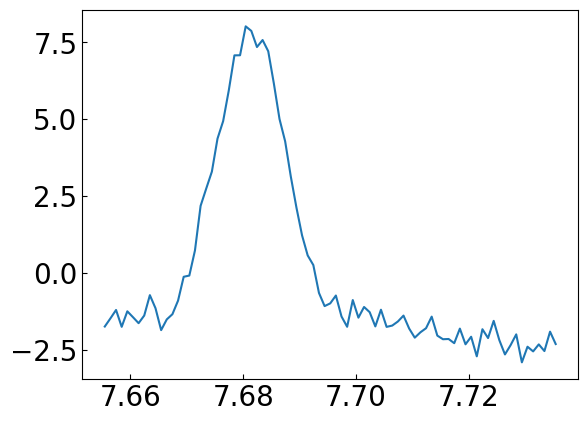

In [153]:
plt.plot(freq, S11_PCA)

In [154]:
par_ini = {
    'amp': 8,
    'const':0,
    'center':7.682,
    'k':0.008
}

par_min = {
    'amp': 0,
    'const':-np.inf,
    'center':0,
    'k':0
}

par_max = {
    'amp': np.inf,
    'const':np.inf,
    'center':np.inf,
    'k':np.inf
}

par_vary = {
    'amp': True,
    'const':True,
    'center':True,
    'k':True
}

In [155]:
model = lmfit.Model(Lorentzian)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = -S11_PCA, params = params, freq = freq)
result

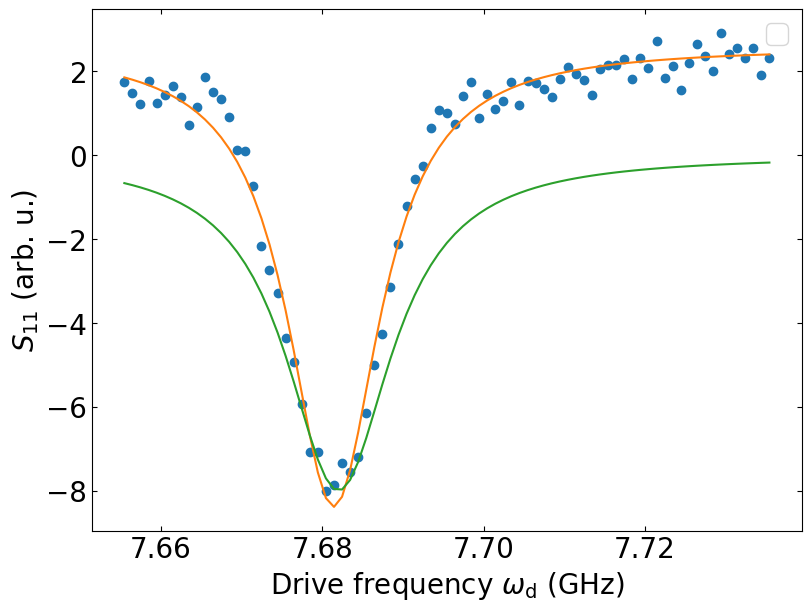

In [156]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

ef amplitude

In [160]:
header = "D:/K_sunada/result/CDY153/"
ef_amp =  "/2024-01-04/2024-01-04T195255_6a5c4b5f-73_active_reset_ef_amp"
dd = datadict_from_hdf5(header + ef_amp +"/data")

S11 = dd['s11']['values'][0:60]
freq = dd['ef_amplitude']['values'][0:60]
S11_PCA = PCA_transform(S11.real, S11.imag)[0]

In [161]:
def cos(x, amp, freq, phi, const):
    return amp * np.cos(2*np.pi*x*freq+phi) + const

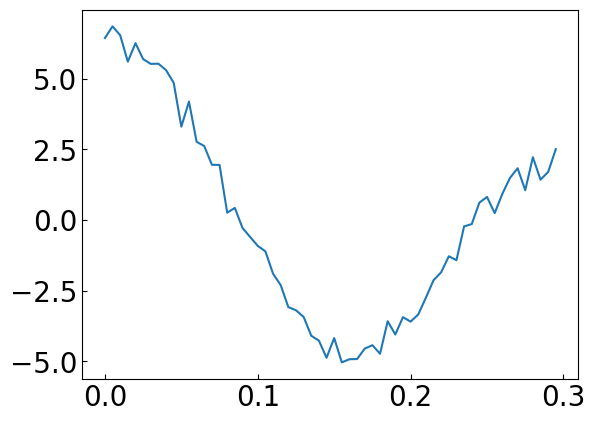

In [162]:
plt.plot(freq, S11_PCA)

In [163]:
par_ini= {'amp': 2,'freq':1/0.4,'phi':np.pi,'const':0}
par_min= {'amp': 0,'freq':0,'phi':-2*np.pi,'const':-np.inf}
par_max= {'amp': np.inf,'freq':np.inf,'phi':2*np.pi,'const':np.inf}
par_vary= {'amp': True,'freq': True,'phi': True,'const': True}

In [164]:
model = lmfit.Model(cos)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini[name],
    min = par_min[name],
    max = par_max[name],
    vary = par_vary[name]
    )
result = model.fit(data = -S11_PCA, params = params, x = freq)
result

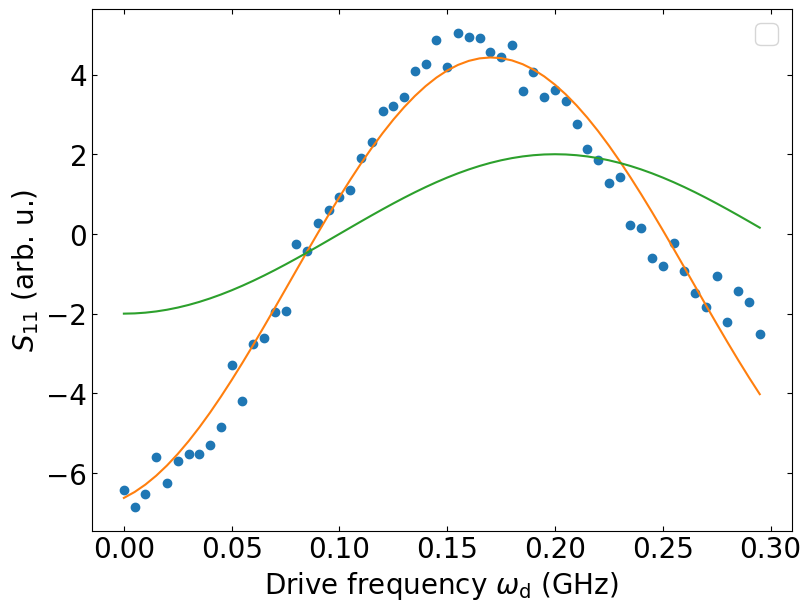

In [165]:
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
result.plot_fit(ax = ax)
plt.plot(freq, result.init_fit)
# plt.xlim(7.95, 8.065)

plt.title("")
plt.legend("")
plt.xlabel("Drive frequency $\omega_\mathrm{d}$ (GHz)")
plt.ylabel("$S_{11}$ (arb. u.)")
# plt.savefig('ge_peak.png', bbox_inches='tight')
plt.show()

In [166]:
1/2/2.67411148

0.18697799390173517

## FFT

In [86]:
def FFT(x, y):
    off_ini = np.mean(y)
    y_mod = y - off_ini
    Y = np.abs(np.fft.fft(y_mod))
    dt = 2e-9
    N = len(y)
    t = x
    f = np.fft.fftfreq(N, dt)
    sorted_idx=np.argsort(f)
    x_fft = f[sorted_idx]
    y_fft = Y[sorted_idx]
    return x_fft, y_fft

In [87]:
def FFT_show(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = (dd['time']['values'])[i]
    y = (dd['waveform']['values'])[i] #- dd['waveform1']['values'] 
    readout_freq = 10.306e9
    readout_if_freq = (10.423-10.306)*1e9
    readout_lo_freq = readout_freq + readout_if_freq

    x_fft = FFT(x, y)[0]
    y_fft = FFT(x, y)[1]

    fig, (ax1, ax2) = plt.subplots(nrows=2)
    ax1.set_xlabel('Time (ns)')
    ax1.set_ylabel('Waveform (V)')
    ax1.plot(x,  y)
    # ax1.plot(x, np.abs(signal.hilbert(y)))
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")

    ax2.set_xlabel('Frequency(Hz)')
    ax2.set_ylabel('Power (arb. u.)')
    ax2.plot(readout_lo_freq-x_fft, y_fft)
    
    ax2.tick_params(axis="x", direction="in")
    ax2.tick_params(axis="y", direction="in")
    # ax2.set_xlim(0, 250e6)
    ax2.set_xlim(readout_lo_freq-250e6, readout_lo_freq)
    peak = readout_lo_freq-x_fft[signal.argrelmax(y_fft, order=100)]

    plt.show()
    return peak, y


In [88]:
def waveform_show(data, i):
    header = "D:/K_sunada/result/CDY152/"
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][i]
    y = dd['waveform']['values'][i]# - dd['waveform1']['values']
    label = dd['fogi_frequency']['values'][i]

    plt.rcParams["font.size"] = 14
    fig, (ax1) = plt.subplots(nrows=1)
    ax1.set_xlabel('Time (ns)', size = "large")
    ax1.set_ylabel('Waveform (V)', size = "large")
    ax1.plot(x,  y)
    ax1.tick_params(axis="x", direction="in")
    ax1.tick_params(axis="y", direction="in")
    plt.tick_params(
                top='on',
                bottom='on`',
                left='on',
                right='on',
               )
    plt.show()
    return label


In [89]:
def LPF(x, samplerate, fp, fs, gpass, gstop):
    fn = samplerate/2
    wp = fp/fn
    ws = fs/fn
    N, Wn = signal.buttord(wp, ws, gpass, gstop)
    b, a = signal.butter(N, Wn, "low")
    y = signal.filtfilt(b, a, x)
    return y

## 1/4 photon shape & photon number

In [90]:
header = "D:/K_sunada/result/CDY153/"

In [91]:
def square(freq, amp, duration):
    x = np.linspace(0, duration-1, duration)
    y = amp* np.cos(2*np.pi* freq*(x*1e-9))
    env = np.zeros(duration) + amp
    return x, y, env

In [92]:
from scipy.constants import *

In [13]:
def photon_number(pulse, freq, atten_fixed, atten_fridge, atten_RT, sample_rate, P_vna):
    #pulse: [x, y, env], atten: dBm, samplerate: s, P_vna: W (when AWG amp=1.0)
    x = pulse[0]
    y = pulse[2] #env

    atten_W = 10**((atten_fixed + atten_fridge + atten_RT)/10)
    ene = 0
    for t in range(int(len(x)/sample_rate*1e-9)):
        ene = ene + (y[2*t]**2)*sample_rate

    return ene * P_vna * atten_W/ (2*np.pi*hbar*freq)


In [385]:
ene = 0
x = [0, 1, 2, 3, 4, 5, 6]
y = [1, 1, 1, 1, 1, 1, 1]
for t in range(int(len(x)/2)):
    ene = ene + (y[2*t]**2)*2

ene

6

Generated photon shape

In [167]:
data = "/2024-01-04/2024-01-04T161954_a8691b2e-70_JPA_photon_generation"
ph_amp = 1000

array([-79999999.99999999,  79999999.99999999])

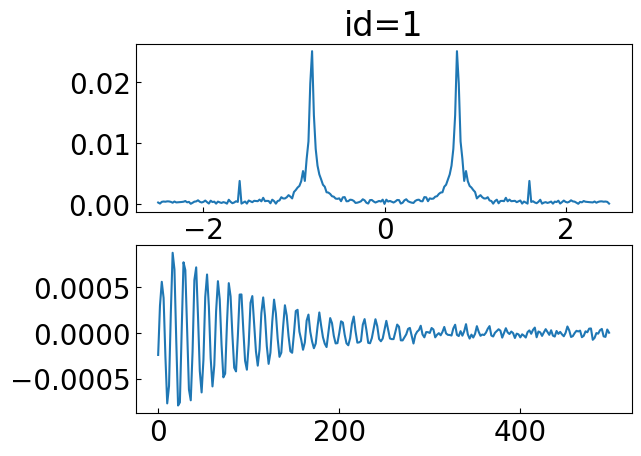

In [191]:
id = 2
duration = 250
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]
x_fft = FFT(x, y)[0]
y_fft = FFT(x, y)[1]

# x_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[0]
# y_fft1 = FFT(np.linspace(0, 260, 260), time_reverse(data, 7,1.2173913e+08, 130)[0])[1]
peak1 = x_fft[signal.argrelmax(y_fft, order=50)]
fig, (ax1, ax2) = plt.subplots(nrows=2)
ax1.set_title("id=1")
ax1.plot(x_fft, y_fft)
ax2.plot(x, y)
peak1

In [ ]:
if_peak = [76, 79, 80, 76, 85, 92.5, 87.5, 80, 95, 80]

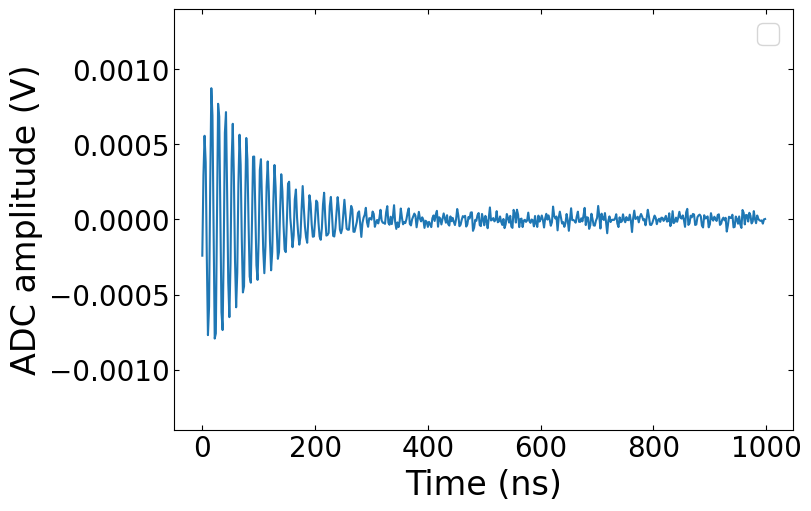

In [201]:
id = 2
duration = 500
data = "/2024-01-04/2024-01-04T161954_a8691b2e-70_JPA_photon_generation"
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][id][0:duration]
y = dd['waveform']['values'][id][0:duration]

fig, ax = plt.subplots(figsize=(8,5),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'

ax.plot(x, y)
plt.title("")
plt.legend("")
ax.set_ylim(-0.0014, 0.0014)
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('ADC amplitude (V)', size='large')
# plt.savefig('photon14.png', bbox_inches='tight')
plt.show()

In [202]:
ph_if =  [76e6, 79e6, 80e6, 76e6, 85e6, 92.5e6, 87.5e6, 80e6, 95e6, 80e6]

## Time-reversed photon shape

In [203]:
def time_reverse(data, id,f_if, duration, awg):
    dd = datadict_from_hdf5(header+data+"/data")
    x = dd['time']['values'][id][0:duration]
    y = dd['waveform']['values'][id][0:duration]
    y = y[::-1]
    y1 =  y* np.exp(-1j*2 *np.pi* f_if*(x*1e-9))
    y_LPF = np.array(np.abs(LPF(y1, 500e6, 10e6, 30e6, 5, 40))*2**0.5)*awg
    
    x_comp = []
    y_comp = []
    for i in range(len(y_LPF)-1):
        x_comp.append(x[i])
        x_comp.append((x[i]+x[i+1])/2)
        y_comp.append(y_LPF[i])
        y_comp.append((y_LPF[i]+y_LPF[i+1])/2)
    x_comp.append(x[-1])
    x_comp.append(x[-1]+1)
    y_comp.append(y_LPF[-1])
    y_comp.append(y_LPF[-1])
    time = np.array(x_comp)
    control_pulse = np.array(y_comp) * np.cos(2*np.pi* f_if*(time*1e-9))
    return x_comp, control_pulse, np.array(y_comp)

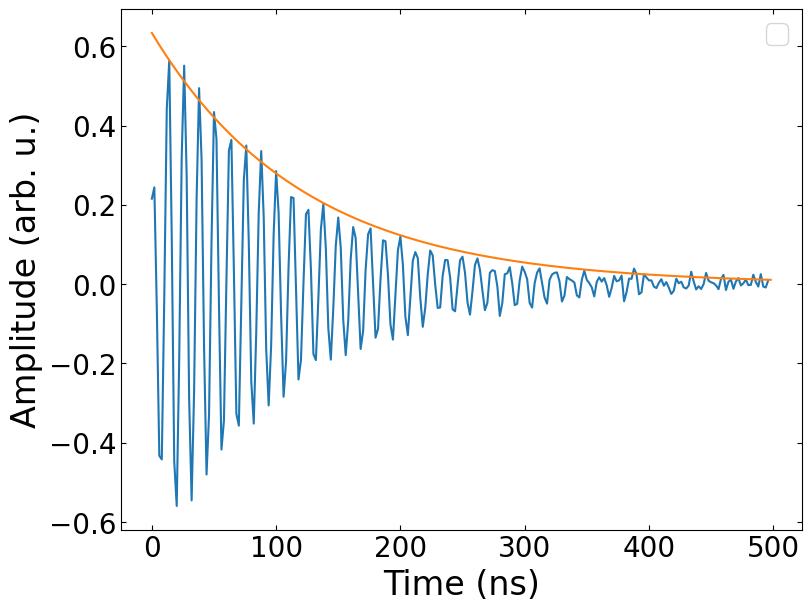

In [563]:
data = "/2024-01-05/2024-01-05T091433_66fecb2f-70_JPA_photon_generation"
data_id = 0
ph_amp = 1000
duratioin = 500
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][data_id]
y = dd['waveform']['values'][data_id]
# y = y[::-1]
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.6335*np.exp(-0.00819161*exp_env_x)

fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.title("")
plt.legend("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')

pulse = time_reverse(data, data_id, ph_if[data_id], 1000, ph_amp)
# plt.title("id=fogi0.6")
plt.plot(x[0:249], y[0:249]*1000/(2**0.5))
plt.plot(exp_env_x[0:499], exp_env_y[0:499])
# plt.plot(pulse[0], pulse[1])
# plt.plot(pulse[0], pulse[2])
x_2 = pulse[0]
LPF_env_2 = pulse[2]
# plt.savefig('orig_waveform.png', bbox_inches='tight')
plt.show()

exponential fiittnig

In [234]:
def Dephase(delay, amp, gamma, const):
    return amp*np.exp(-gamma*delay) + const

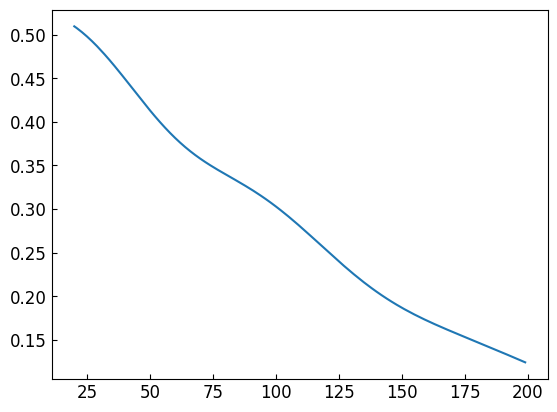

In [242]:
# plt.plot(x_2, LPF_env_2[::-1])
plt.plot(x_2[20:200], LPF_env_2[::-1][20:200])

In [254]:
par_ini_t1 = {'gamma': 1/400,'amp':0.4,'const':0}
par_min_t1 = {'gamma': 0,'amp':0,'const':-np.inf}
par_max_t1 = {'gamma': np.inf,'amp':np.inf,'const':np.inf,}
par_vary_t1 = {'gamma': True,'amp':True,'const':False}

In [258]:
model = lmfit.Model(Dephase)

params = model.make_params()
for name in model.param_names:
    params[name].set(
    value = par_ini_t1[name],
    min = par_min_t1[name],
    max = par_max_t1[name],
    vary = par_vary_t1[name]
    )
# result1 = model.fit(data = LPF_env_1[::-1][50:], params = params, delay = x_1[50:])
result2 = model.fit(data = LPF_env_2[::-1][20:400], params = params, delay = x_2[20:400])

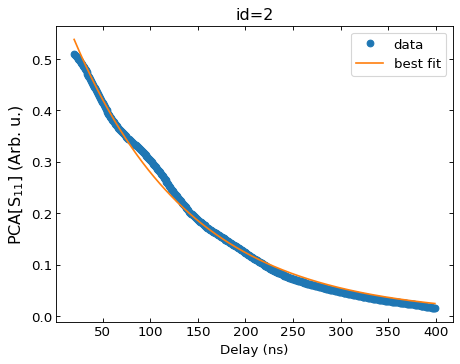

In [259]:
fig, (ax) = plt.subplots(dpi=80)
plt.title("id=2")
plt.rcParams["font.size"] = 12
plt.tick_params(top='on',bottom='on',left='on',right='on',)
result2.plot_fit(ax = ax)
# plt.plot(x_2,result2.init_fit, label='init fit')

# ax.set_ylim(-8, 15)
ax.tick_params(axis="x", direction="in")
ax.tick_params(axis="y", direction="in")
ax.set_xlabel('Delay (ns)')#, size='large')
ax.set_ylabel('PCA[S$_{11}$] (Arb. u.)', size='large')

plt.show()
result2

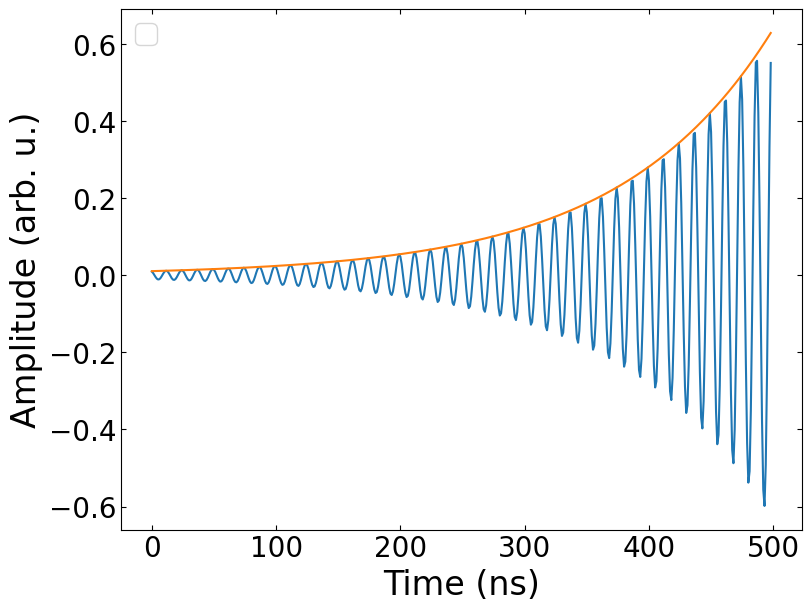

In [558]:
data =  "/2024-01-05/2024-01-05T091433_66fecb2f-70_JPA_photon_generation"
data_id = 0
ph_amp = 1000
duratioin = 500
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][data_id][0:duration]
y = dd['waveform']['values'][data_id][0:duration]
y = y[::-1]

fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
pulse = time_reverse(data, data_id, ph_if[2], 1000, ph_amp)
plt.title("")
plt.legend("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')
# plt.plot(x[300:499], y[300:499]*1000/(2**0.5))
# plt.plot(pulse[0], pulse[1])
# plt.plot(pulse[0], pulse[2])
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.6335*np.exp(-0.00819161*exp_env_x)
exp_y = exp_env_y* np.cos(2*np.pi* ph_if[2]*(exp_env_x*1e-9))
# plt.plot(exp_env_x[600:999], exp_env_y[::-1][600:999])
plt.plot(exp_env_x[500:999]-500, exp_y[::-1][500:999])
plt.plot(exp_env_x[500:999]-500, exp_env_y[::-1][500:999])
# plt.savefig('tr_waveform.png', bbox_inches='tight')
plt.show()

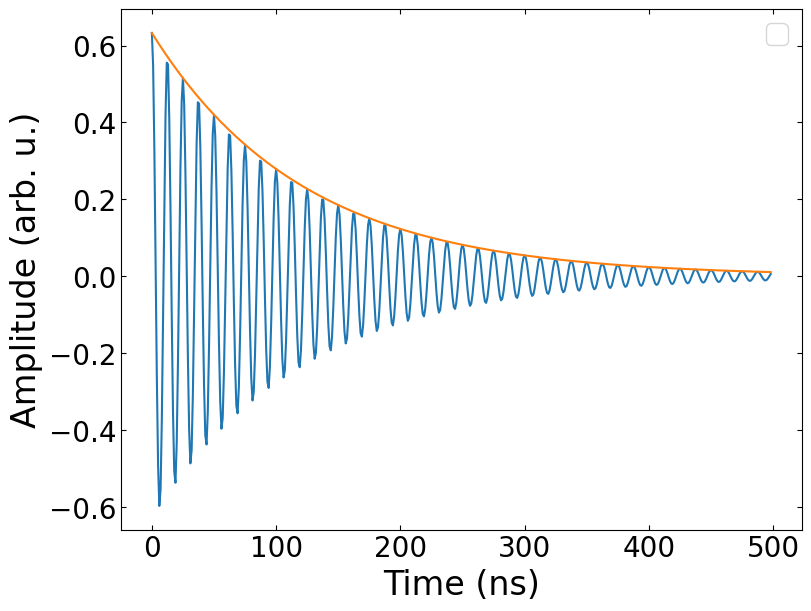

In [559]:
data =  "/2024-01-05/2024-01-05T091433_66fecb2f-70_JPA_photon_generation"
data_id = 0
ph_amp = 1000
duratioin = 500
dd = datadict_from_hdf5(header+data+"/data")
x = dd['time']['values'][data_id][0:duration]
y = dd['waveform']['values'][data_id][0:duration]
y = y[::-1]

fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
pulse = time_reverse(data, data_id, ph_if[2], 1000, ph_amp)
plt.title("")
plt.legend("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')
# plt.plot(x[300:499], y[300:499]*1000/(2**0.5))
# plt.plot(pulse[0], pulse[1])
# plt.plot(pulse[0], pulse[2])
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.6335*np.exp(-0.00819161*exp_env_x)
exp_y = exp_env_y* np.cos(2*np.pi* ph_if[2]*(exp_env_x*1e-9))
# plt.plot(exp_env_x[600:999], exp_env_y[::-1][600:999])
plt.plot(exp_env_x[500:999]-500, exp_y[500:999]*60)
plt.plot(exp_env_x[500:999]-500, exp_env_y[500:999]*60)
# plt.savefig('utr_waveform.png', bbox_inches='tight')
plt.show()

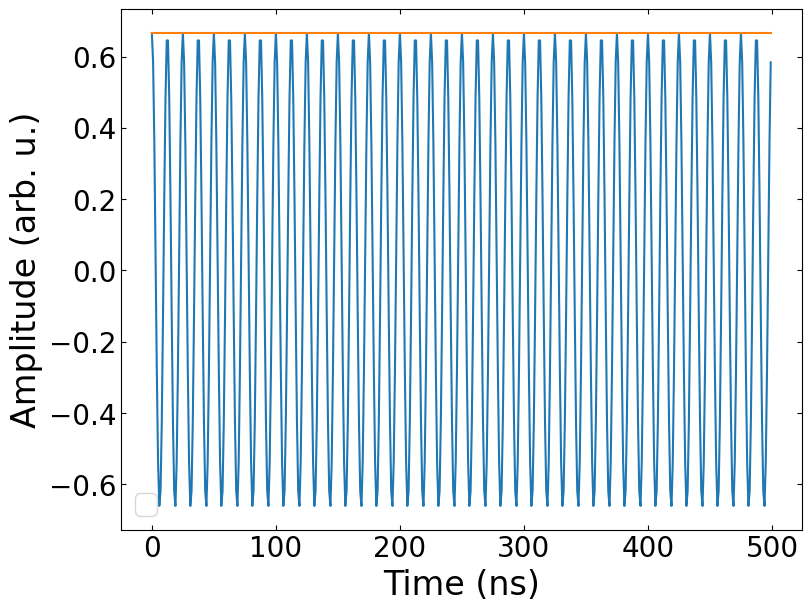

In [571]:
## square 0.03-1.21
fig, ax = plt.subplots(figsize=(8,6),constrained_layout=True)
plt.rcParams["font.size"] = 20
# plt.title("Rabi(amp)")
plt.tick_params(top='on',bottom='on',left='on',right='on',)
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["ytick.direction"] = 'in'
plt.title("")
plt.legend("")
ax.set_xlabel('Time (ns)', size='large')
ax.set_ylabel('Amplitude (arb. u.)', size='large')

ph_amp_id = 0
ph_amp =0.222#[0.222, 0.405,0.573, 0.702, 0.811] #[0.7, 1.28, 1.81, 2.22, 2.56](1 + 0.5 * ph_amp_id)
pulse = np.array(square(80e6, 0.05, 500) )* ph_amp

plt.plot(pulse[0]/ph_amp, pulse[1]*60)
plt.plot(pulse[0]/ph_amp, pulse[2]*60)
# plt.savefig('sq_waveform.png', bbox_inches='tight')
plt.show()

In [261]:
3/0.00819161

366.2283726886412

photon number

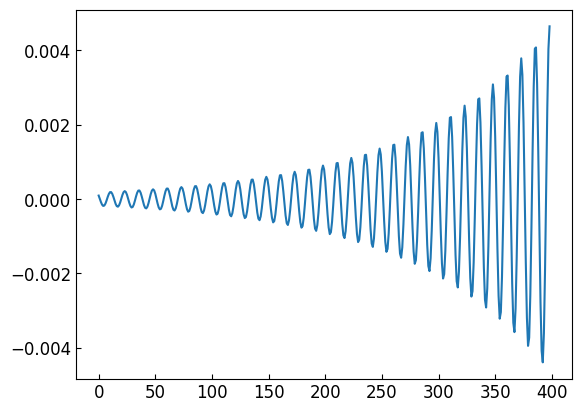

In [384]:
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.6335*np.exp(-0.00819161*exp_env_x)
exp_y = (exp_env_y* np.cos(2*np.pi* ph_if[2]*(exp_env_x*1e-9)))
time_reversed_waveform = np.array( exp_y[600:999])[::-1]
plt.plot(exp_env_x[0:399], time_reversed_waveform)

In [504]:
exp_env_x = np.linspace(0, 999, 1000)
exp_env_y =0.6335*np.exp(-0.00819161*exp_env_x)
exp_y = (exp_env_y* np.cos(2*np.pi* ph_if[2]*(exp_env_x*1e-9)))

ph_amp_id = 0
ph_amp =11.06#(10dB)[3.03, 5.53, 7.83, 9.6, 11.07] #[9.6, 17.5, 24.8, 30.3, 35]#(10 + 5* ph_amp_id) 
pulse = (exp_env_x[500:999]-500, exp_y[500:999][::-1],np.array( exp_env_y[500:999]*ph_amp)[::-1])
rf_freq = readout_lo_freq-80e6
atten_fixed = -53.57
atten_fridge = -20
atten_RT = -30 + 10
sample_rate = 2e-9
P_vna =  7.6e-6
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)
# plt.plot(pulse[0], pulse[2])
# plt.plot(pulse[0], pulse[1]*ph_amp)

0.3994796553569239

In [ ]:
pn_tr_0108 = [0.03, 0.1, 0.2, 0.3, 0.4] 

In [361]:
pn_tr = [0.040, 0.112, 0.221, 0.366, 0.548, 0.767, 1.022, 1.314, 1.643]
pn_tr_500 = [0.033, 0.106, 0.221, 0.378, 0.576, 0.816, 1.10, 1.423, 1.79]

In [543]:
## square 0.03-1.21
ph_amp_id = 0
ph_amp =0.222#[0.222, 0.405,0.573, 0.702, 0.811] #[0.7, 1.28, 1.81, 2.22, 2.56](1 + 0.5 * ph_amp_id)
pulse = np.array(square(80e6, 0.05, 500) )* ph_amp
readout_lo_freq = 10.38e9
rf_freq = readout_lo_freq-80e6
atten_fixed = -53.57
atten_fridge = -20
atten_RT = -30 + 10
sample_rate = 2e-9
P_vna =  7.6e-6
photon_number(pulse, rf_freq, atten_fixed, atten_fridge, atten_RT, sample_rate,P_vna)
# plt.plot(pulse[0], pulse[2])
# plt.plot(pulse[0], pulse[1])

0.030032787172579838

In [ ]:
pn_squ = [0.049, 0.125, 0.237, 0.384, 0.566, 0.783, 1.036, 1.323, 1.646]
pn_sq_500 = [0.061, 0.137, 0.244, 0.381, 0.548, 0.746, 0.975, 1.23, 1.52]

: 

: 

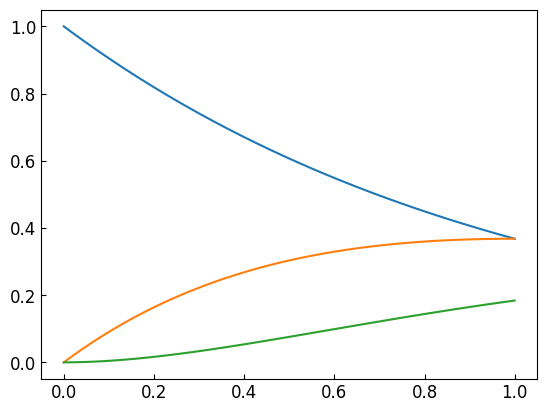

In [390]:
x = np.linspace(0, 1, 101)
y0 = np.exp(-x)
y1 = np.exp(-x)*x
y2 = np.exp(-x) * x**2/2
plt.plot(x, y0)
plt.plot(x, y1)
plt.plot(x, y2)